### ordner löschen mit Namen xx

In [52]:
# ### sachen löschen mit namen xx
# import os
# import shutil

# # Define the path
# path = r'C:\Users\rehan\meine_Repos\Masterarbeit\04_beispiel_mit_simulierten_survival_data\sim_shape_1_5__B1000\499'

# # Iterate over all items in the directory
# for folder_name in os.listdir(path):
#     folder_path = os.path.join(path, folder_name)
    
#     # Check if it's a directory and does not contain '(B_RF) 2000'
#     if os.path.isdir(folder_path) and '(B_RF) 2000' not in folder_name:
#         try:
#             print(f"Deleting folder: {folder_path}")
#             shutil.rmtree(folder_path)  # Delete the folder and its contents
#         except FileNotFoundError as e:
#             print(f"Error: {e} - Folder not found, skipping.")
#         except OSError as e:
#             print(f"Error: {e} - Unable to delete the folder.")


### Summary csv erstellen

In [53]:
# Define the path

n = 3999
B = 4000


path = r'C:\Users\rehan\meine_Repos\Masterarbeit\04_beispiel_mit_simulierten_survival_data\sim_shape_1___B4000\3999'

save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\04_beispiel_mit_simulierten_survival_data\sim_shape_1___B4000'

In [54]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Funktion zum Extrahieren der benötigten Informationen aus der Datei results.txt
def extract_data_from_txt(path):
    with open(path, 'r') as file:
        content = file.read()

        # Extrahieren der Events und Censored Anteile
        events_prop = re.search(r"Events:\s+(\d+\.\d+)\s+%", content)
        censored_prop = re.search(r"Censored:\s+(\d+\.\d+)\s+%", content)

        # Extrahieren der IJK STD Daten
        ijk_std = re.search(r"IJK STD \(for RF\) Mean-est\s+:\s+(\d+\.\d+)", content)
        ijk_std_rel_error = re.search(r"rel\. Abweichung zu emp\. std ([\-\d\.]+) %", content)
        ijk_std_cv = re.search(r"std\. des schätzers (\d+\.\d+)", content)

        # Extrahieren der JK-AB STD Daten
        jkab_std = re.search(r"JK-AB\(un-weighted\) STD \(for RF\) Mean-est:\s+(\d+\.\d+)", content)
        
        # Extrahieren der JK-AB STD Daten aus der 12. Zeile
        lines = content.splitlines()  # Datei in Zeilen aufteilen
        if len(lines) >= 12:
            line_12 = lines[11]  # Zeile 12 extrahieren (Index 11, da 0-basiert)
            jkab_std_rel_error = re.search(r"rel\. Abweichung zu emp\. std ([\d\.]+) %", line_12)
        else:
            jkab_std_rel_error = None  # Keine 12. Zeile vorhanden
        
        line_13 = lines[12]
        jkab_std_cv= re.search(r"std\. des schätzers (\d+\.\d+)", line_13)
        

        # Extrahieren der Prediction Results
        true_y = re.search(r"True Y:\s+(\d+\.\d+)", content)
        rf_y_pred = re.search(r"RF Y_pred:\s+(\d+\.\d+)", content)

        # Erstellen eines Dictionaries mit den extrahierten Daten
        data = {
            'censored_proportion': round(float(censored_prop.group(1))/100,1) if censored_prop else None,
            'events_proportion': round(float(events_prop.group(1))/100,2) if events_prop else None,
            'ijk_std': float(ijk_std.group(1)) if ijk_std else None,
            'ijk_std_rel_error(%)': float(ijk_std_rel_error.group(1)) if ijk_std_rel_error else None,
            'ijk_std_cv': float(ijk_std_cv.group(1))/float(ijk_std.group(1)) if ijk_std_cv else None,
            'jkab_std': float(jkab_std.group(1)) if jkab_std else None,
            'jkab_std_rel_error(%)': float(jkab_std_rel_error.group(1)) if jkab_std_rel_error else None,
            'jkab_std_cv': float(jkab_std_cv.group(1))/float(jkab_std.group(1)) if jkab_std_cv else None,
            'True_Y': float(true_y.group(1)) if true_y else None,
            'RF_Y_pred': float(rf_y_pred.group(1)) if rf_y_pred else None
        }
        
        return data

# Hauptfunktion, um alle Unterordner zu durchlaufen und die Daten zu extrahieren
def process_folders(main_folder):
    data_list = []

    # Durchlaufen aller Ordner im Hauptordner
    for folder_name in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder_name)

        # Überprüfen, ob der Pfad ein Verzeichnis ist
        if os.path.isdir(folder_path):
            result_file_path = os.path.join(folder_path, 'results.txt')

            # Überprüfen, ob die results.txt existiert
            if os.path.exists(result_file_path):
                # Daten aus der Datei extrahieren
                data = extract_data_from_txt(result_file_path)
                data_list.append(data)

    # Erstellen eines DataFrames aus der Liste der extrahierten Daten
    df = pd.DataFrame(data_list)

    # Anzeigen des DataFrames
    return df


df = process_folders(path)
df_sorted = df.sort_values(by=['censored_proportion', 'events_proportion'], ascending=[True, True])
print(df_sorted)
df_sorted['events_bin'] = ['EE1', 'EE2', 'EE3', 'EE4', 'EE1', 'EE2', 'EE3', 'EE4', 'EE1', 'EE2', 'EE3', 'EE4', 'EE1', 'EE2', 'EE3', 'EE4']
df_sorted.to_csv(os.path.join(path, 'results_summary.csv'), index=False)
#print(df_sorted)
df_sorted = pd.read_csv(os.path.join(path, 'results_summary.csv'))

    censored_proportion  events_proportion  ijk_std  ijk_std_rel_error(%)  \
7                   0.1               0.09   0.0115                3.3205   
13                  0.1               0.18   0.0203                5.2628   
0                   0.1               0.27   0.0284                1.1643   
3                   0.1               0.36   0.0363                0.5083   
6                   0.3               0.07   0.0119               11.9158   
11                  0.3               0.14   0.0212               12.8311   
15                  0.3               0.21   0.0296                7.0415   
1                   0.3               0.28   0.0385                7.7271   
4                   0.5               0.05   0.0126               26.2589   
9                   0.5               0.10   0.0220               19.4163   
12                  0.5               0.15   0.0309               24.5591   
14                  0.5               0.20   0.0395               14.9109   

### Plot aus Summary csv erstellen

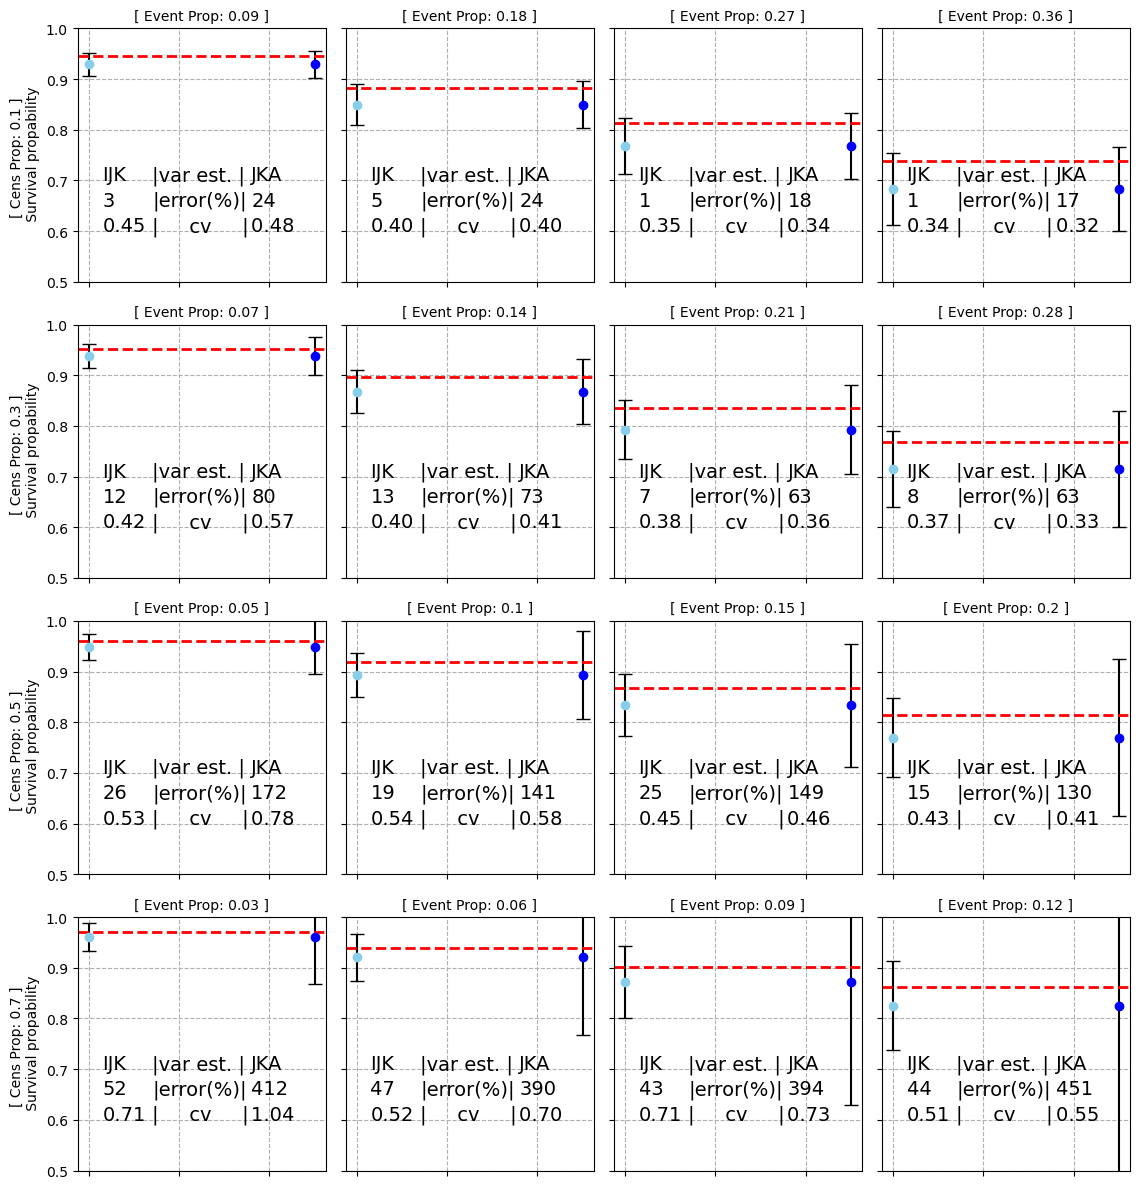

In [55]:
data = df_sorted

# Schritt 2: Einzigartige Werte von 'censored_proportion' und 'events_bin' ermitteln
censored_values = sorted(data['censored_proportion'].unique())
events_bins = ['EE1', 'EE2', 'EE3', 'EE4']

# Dictionaries für die Indizierung erstellen
censored_indices = {value: idx for idx, value in enumerate(censored_values)}
events_indices = {label: idx for idx, label in enumerate(events_bins)}

# Schritt 3: Erstellen des 4x4 Grids
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(11.5, 12), sharex=True, sharey=True)

# Schritt 4: Plotten der Daten mit Errorbars und Textinformationen
for idx, row in data.iterrows():
    censored = row['censored_proportion']
    event_bin = row['events_bin']
    True_Y = row['True_Y']
    RF_Y_pred = row['RF_Y_pred']
    ijk_std = row['ijk_std']
    jkab_std = row['jkab_std']
    ijk_std_rel_error = row['ijk_std_rel_error(%)']
    ijk_std_cv = row['ijk_std_cv']  # Achte auf den Leerraum im Spaltennamen
    jkab_std_rel_error = row['jkab_std_rel_error(%)']
    jkab_std_cv = row['jkab_std_cv']
    
    row_idx = censored_indices[censored]
    col_idx = events_indices[event_bin]
    ax = axes[row_idx, col_idx]
    
    # Fehlerbalken berechnen: 1.96 * ijk_std
    error_ijk = 1.96 * ijk_std
    error_jkab = 1.96 * jkab_std
    
    # Zeichne die Errorbars
    ax.errorbar(0, RF_Y_pred, yerr=error_ijk, fmt='o', color='skyblue', ecolor='black', capsize=5)
    ax.errorbar(0.5, RF_Y_pred, yerr=error_jkab, fmt='o', color='blue', ecolor='black', capsize=5)
    
    # Rote horizontale Linie für True_Y
    ax.axhline(y=True_Y, color='red', linestyle='--', linewidth=2)
    
    # Setze die Y-Achse auf den Bereich [0, 1]
    ax.set_ylim(0.5, 1)
    
    # Titel setzen (events_proportion über dem Plot)
    ax.set_title(f'[ Event Prop: {row["events_proportion"]} ]', fontsize=10)
    
    # Y-Achsenbeschriftung für die erste Spalte
    if col_idx == 0:
        ax.set_ylabel(f'[ Cens Prop: {censored} ] \n Survival propability', fontsize=10)
    
    # Werte für ijk_std_rel_error, ijk_std_cv, jkab_std_rel_error und jkab_std_cv als Text hinzufügen
    fz = 14
    ax.text(0.1, 0.4, f'IJK', fontsize=fz, transform=ax.transAxes)
    ax.text(0.3, 0.4, f'|var est. |', fontsize=fz, transform=ax.transAxes)
    ax.text(0.1, 0.3, f'{ijk_std_rel_error:.0f}', fontsize=fz, transform=ax.transAxes)
    ax.text(0.3, 0.3, f'|error(%)|', fontsize=fz, transform=ax.transAxes)
    ax.text(0.7, 0.3, f'{jkab_std_rel_error:.0f}', fontsize=fz, transform=ax.transAxes)
    
    ax.text(0.7, 0.4, f'JKA', fontsize=fz, transform=ax.transAxes)
    ax.text(0.1, 0.2, f'{ijk_std_cv:.2f}', fontsize=fz, transform=ax.transAxes)
    ax.text(0.3, 0.2, f'|     cv     |', fontsize=fz, transform=ax.transAxes)
    ax.text(0.7, 0.2, f'{jkab_std_cv:.2f}  ', fontsize=fz, transform=ax.transAxes)
    
    # Gridlines optional hinzufügen
    ax.grid(True, linestyle='--', alpha=1.)
    
    # X-Achsenbeschriftung entfernen
    ax.set_xticklabels([])

# Schritt 5: Achsenbeschriftungen und Layout anpassen
# Leere Unterplots deaktivieren
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if not ax.has_data():
            ax.axis('off')
# Layout anpassen
plt.tight_layout() # Anpassung, um Platz für gemeinsame Beschriftungen zu schaffen
plt.show()

fig.savefig(os.path.join(save_path, f'n_train{n}_B_{B}_shape_1_5.png'), dpi=300)